# Baseline Detection with Drawing

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import cv2
import json

In [2]:
# Constants
frame = "../results/player-detection/test_image.png"
schema = "../results/schema.png"

## 1. Important Points on Frame and Schema

- The frame is the image to be processed.
- The shema is a drawing of a basketball court with the right dimensions.

You need to select important points in this order:
1. Top Left corner of the side
2. Top Right corner of the side
3. Bottom Right corner of the side
4. Bottom Left corner of the side
---
5. Top Left corner of the three-point endline
6. Top Right corner of the three-point endline
7. Bottom Right corner of the three-point endline
8. Bottom Left corner of the three-point endline
---
9. Top Left corner of the lane line
10. Top Right corner of the lane line
11. Bottom Right corner of the lane line
12. Bottom Left corner of the lane line


In [3]:
frame_coordinates = []

with open("frame.json", "r") as f:
    data = json.load(f)
    frame_coordinates = data

frame_coordinates

[[77, 525],
 [1031, 448],
 [1533, 847],
 [123, 1017],
 [858, 483],
 [1054, 467],
 [1488, 811],
 [1225, 845],
 [743, 591],
 [1163, 552],
 [1319, 675],
 [849, 724]]

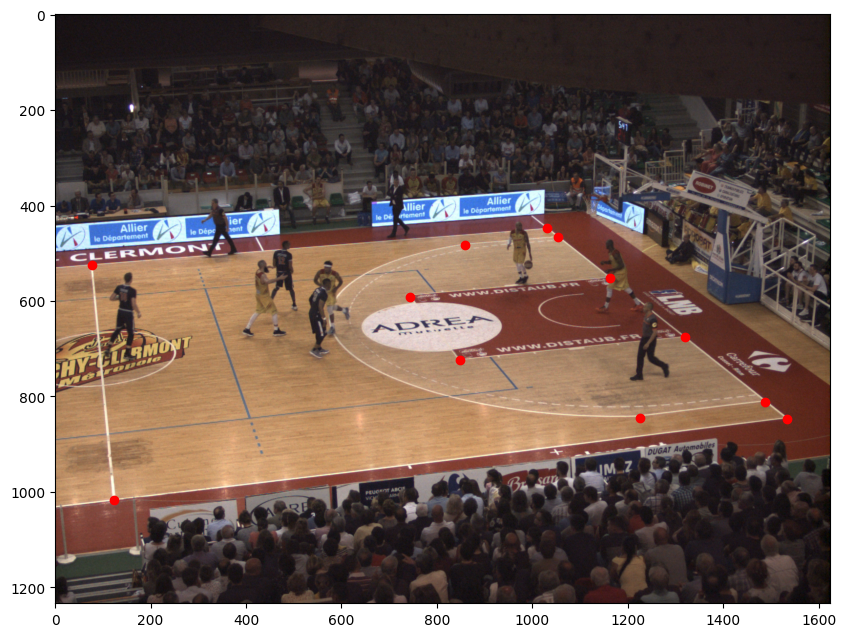

In [4]:
img_frame = plt.imread(frame)

plt.figure(figsize=(10, 10))
plt.imshow(img_frame)
for point in frame_coordinates:
    plt.scatter(point[0], point[1], color="red")
plt.show()

In [5]:
schema_coordinates = []

with open("schema.json", "r") as f:
    data = json.load(f)
    schema_coordinates = data

schema_coordinates

[[455, 57],
 [852, 58],
 [854, 484],
 [455, 484],
 [766, 84],
 [852, 85],
 [852, 457],
 [767, 457],
 [689, 202],
 [852, 203],
 [852, 339],
 [689, 339]]

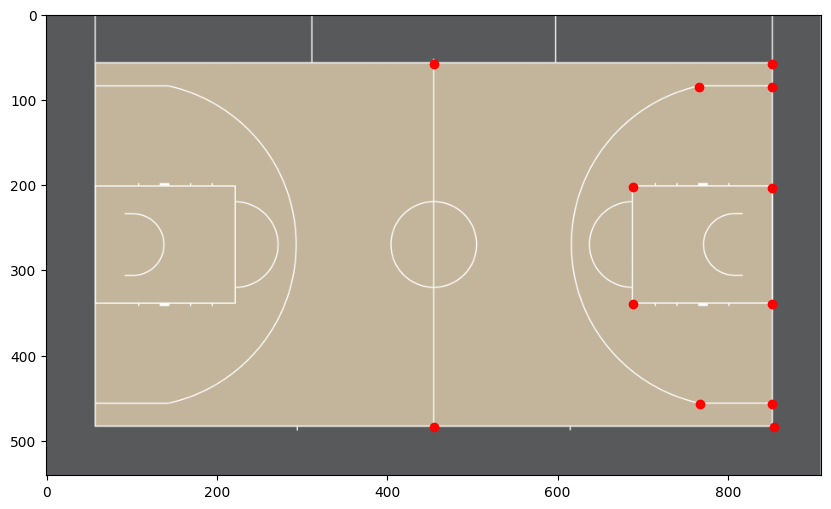

In [6]:
img_schema = plt.imread(schema)

plt.figure(figsize=(10, 10))
plt.imshow(img_schema)
for point in schema_coordinates:
    plt.scatter(point[0], point[1], color="red")
plt.show()

## 2. Homography Calculation

In [7]:
frame_points = np.array(frame_coordinates, dtype=np.float32)
schema_points = np.array(schema_coordinates, dtype=np.float32)

H, _ = cv2.findHomography(schema_points, frame_points)
H_inv, _ = cv2.findHomography(frame_points, schema_points)

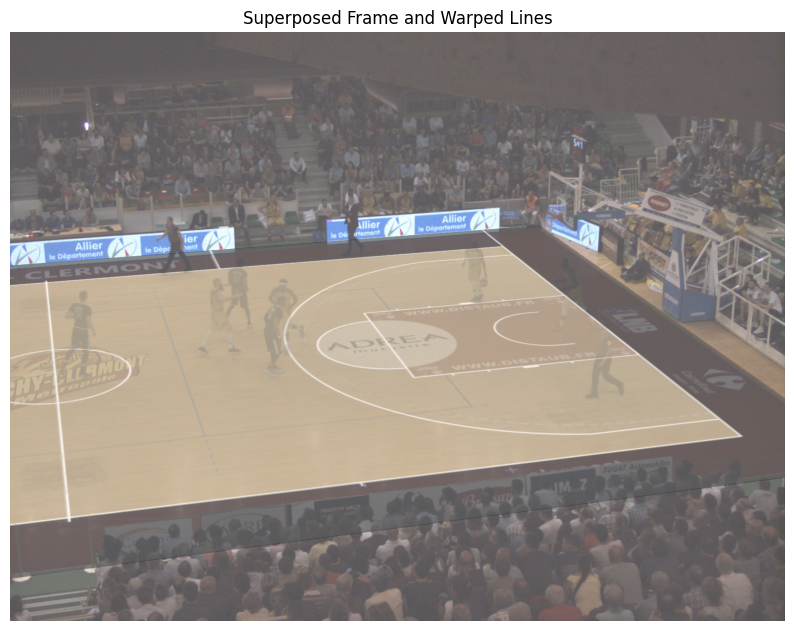

In [8]:
# Modify the alpha values to adjust the transparency of the images
alpha_frame = 0.7
alpha_schema = 0.7


warped_lines = cv2.warpPerspective(
    img_schema, H, (img_frame.shape[1], img_frame.shape[0])
)

plt.figure(figsize=(10, 10))
plt.imshow(img_frame, alpha=alpha_frame)
plt.imshow(warped_lines, alpha=alpha_schema, cmap="viridis")
plt.axis("off")
plt.title("Superposed Frame and Warped Lines")
plt.show()

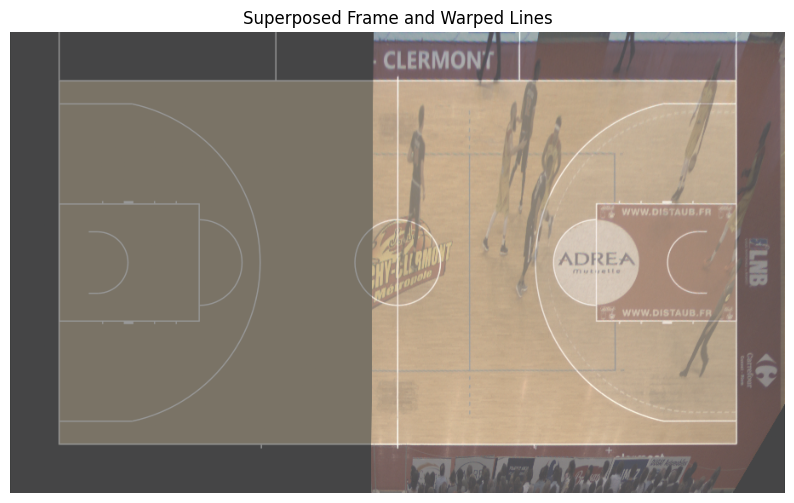

In [9]:
# Modify the alpha values to adjust the transparency of the images
inv_alpha_frame = 0.8
inv_alpha_schema = 0.5


inv_warped_lines = cv2.warpPerspective(
    img_frame, H_inv, (img_schema.shape[1], img_schema.shape[0])
)

plt.figure(figsize=(10, 10))
plt.imshow(inv_warped_lines, alpha=inv_alpha_frame, cmap="viridis")
plt.imshow(img_schema, alpha=inv_alpha_schema)
plt.axis("off")
plt.title("Superposed Frame and Warped Lines")
plt.show()

## 3. Line Identification

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


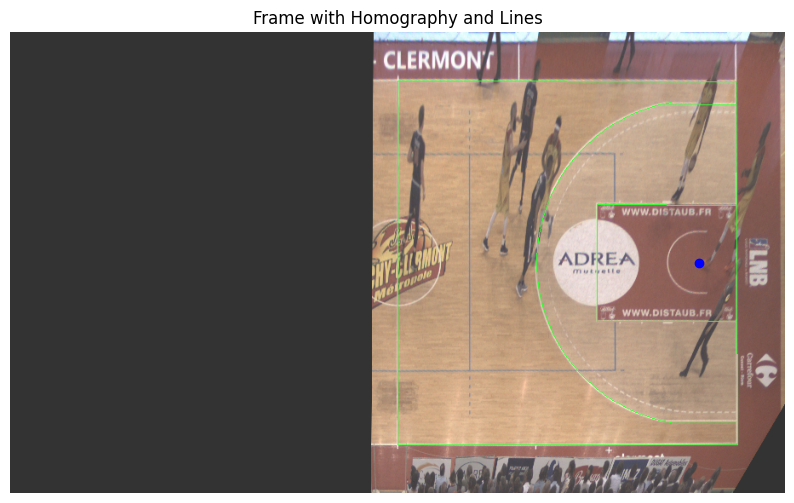

In [10]:
def draw_line_between_points(image, point1, point2):
    # Convert points to integers
    point1 = tuple(map(int, point1))
    point2 = tuple(map(int, point2))

    # Draw line on the image
    cv2.line(image, point1, point2, (0, 255, 0), 1)

    return image


# Draw court baseline
# Sideline
result = draw_line_between_points(
    inv_warped_lines, schema_coordinates[0], schema_coordinates[1]
)
result = draw_line_between_points(
    inv_warped_lines, schema_coordinates[1], schema_coordinates[2]
)
result = draw_line_between_points(
    inv_warped_lines, schema_coordinates[2], schema_coordinates[3]
)
result = draw_line_between_points(
    inv_warped_lines, schema_coordinates[3], schema_coordinates[0]
)

# 3-points Line
result = draw_line_between_points(
    inv_warped_lines, schema_coordinates[4], schema_coordinates[5]
)
result = draw_line_between_points(
    inv_warped_lines, schema_coordinates[6], schema_coordinates[7]
)
# Draw the half-circle
center_1 = (
    int((schema_coordinates[4][0] + schema_coordinates[7][0]) / 2),
    int((schema_coordinates[4][1] + schema_coordinates[7][1]) / 2),
)  # Center between points 5 and 6
center = (
    int((center_1[0] + schema_coordinates[1][0]) / 2),
    int(center_1[1]),
)  # Center of the basket position, between axis x of center_1 and point 2

radius = int(
    np.linalg.norm(np.array(schema_coordinates[4]) - np.array(schema_coordinates[7]))
    / 2
)
radius = radius + 5  # Need explanations for the small offset incrementation

cv2.ellipse(result, center, (radius, radius), 100, 0, 160, (0, 255, 0), 1)

# Lane Lines
result = draw_line_between_points(
    inv_warped_lines, schema_coordinates[8], schema_coordinates[9]
)
result = draw_line_between_points(
    inv_warped_lines, schema_coordinates[10], schema_coordinates[11]
)
result = draw_line_between_points(
    inv_warped_lines, schema_coordinates[11], schema_coordinates[8]
)


# Display the image with lines
plt.figure(figsize=(10, 10))
plt.imshow(result, alpha=inv_alpha_frame, cmap="viridis")
plt.scatter(center[0], center[1], color="blue")  # Basket position
plt.axis("off")
plt.title("Frame with Homography and Lines")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


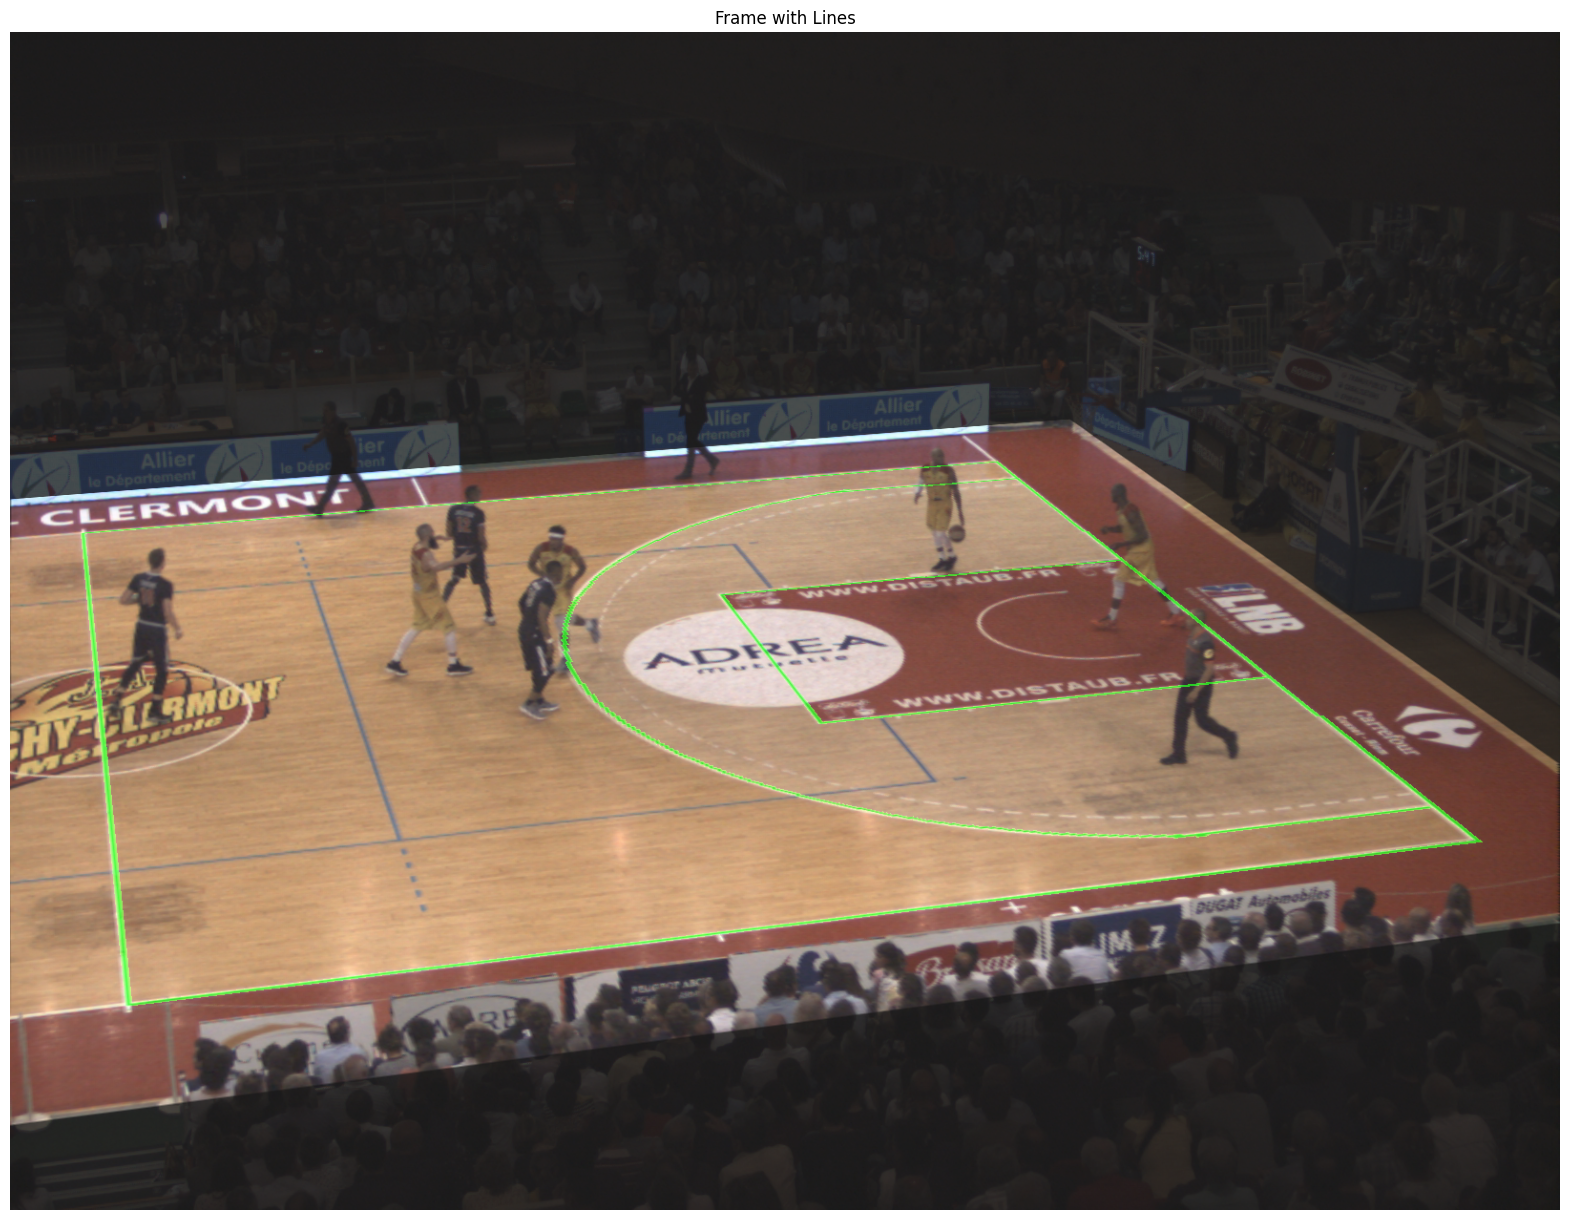

In [11]:
new_res = cv2.warpPerspective(result, H, (img_frame.shape[1], img_frame.shape[0]))

plt.figure(figsize=(20, 20))
plt.imshow(img_frame, alpha=alpha_frame)
plt.imshow(new_res, alpha=alpha_schema, cmap="viridis")
plt.axis("off")
plt.title("Frame with Lines")
plt.show()

## 4. Player Detection in the Court Area

In [12]:
# # Generate coordinates of the court area
# court_area = np.array([schema_coordinates[0], schema_coordinates[1], schema_coordinates[2], schema_coordinates[3]], dtype=np.float32)
# court_area = np.array(court_area, dtype=np.int32)

# print("x_min", )
# print("y_min", )

# print("schema_coordinates:", schema_coordinates)
# print("court_area:", court_area)

# x_min = np.min(court_area[:, 0])
# x_max = np.max(court_area[:, 0])
# y_min = np.min(court_area[:, 1])
# y_max = np.max(court_area[:, 1])

# print("x_min, x_max, y_min, y_max", x_min, x_max, y_min, y_max)

# # Load YOLOv8 model
# model = YOLO("yolov8n.pt")

# # Load new_res image
# image = cv2.imread(frame)
# height, width = image.shape[:2]  # Get image dimensions
# results = model(image)

# # Extract bounding boxes of detected persons
# players = []
# border_margin = 200

# for result in results[0].boxes:  # Access the first image's detections
#     # print(result)
#     x1, y1, x2, y2 = result.xyxy[0].tolist()
#     conf = result.conf[0].item()
#     class_id = result.cls[0].item()

#     # Only add players that are in the court area
#     if (class_id == 0):  # Class 0 in COCO is 'person'
#         print("Add player", x1, x2, y1, y2)
#         players.append((int(x1), int(y1), int(x2), int(y2)))

# print(players)


In [13]:
# # Create a copy of the image for visualization
# vis_image = new_res.copy()

# # # Draw border margin rectangle
# # cv2.rectangle(vis_image,
# #              (0, border_margin),
# #              (width, height - border_margin),
# #              (0, 0, 255),  # Red color
# #              2)  # Line thickness

# # Draw bounding boxes for all detected players
# for (x1, y1, x2, y2) in players:
#     cv2.rectangle(vis_image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

# cv2.circle(vis_image, (x_min, y_min), radius=5, color=(255, 0, 0), thickness=-1)
# cv2.circle(vis_image, (x_max, y_max), radius=5, color=(255, 0, 0), thickness=-1)


# # # Convert BGR to RGB for matplotlib display
# # vis_image_rgb = cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB)

# # Display the image
# plt.figure(figsize=(12, 8))
# plt.imshow(vis_image)
# plt.axis('off')
# plt.title(f'Detected Players ({len(players)} players)')
# plt.show()